In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [5]:
df = pd.read_csv("Advertising.csv")


In [6]:
print("Dataset loaded successfully!")
print("\nFirst 5 rows of dataset:")
print(df.head())

Dataset loaded successfully!

First 5 rows of dataset:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [7]:

df['total_spend'] = df['TV'] + df['Radio'] + df['Newspaper']


In [8]:
print(df.describe())

       Unnamed: 0          TV       Radio   Newspaper       Sales  total_spend
count  200.000000  200.000000  200.000000  200.000000  200.000000   200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500   200.860500
std     57.879185   85.854236   14.846809   21.778621    5.217457    92.985181
min      1.000000    0.700000    0.000000    0.300000    1.600000    11.700000
25%     50.750000   74.375000    9.975000   12.750000   10.375000   123.550000
50%    100.500000  149.750000   22.900000   25.750000   12.900000   207.350000
75%    150.250000  218.825000   36.525000   45.100000   17.400000   281.125000
max    200.000000  296.400000   49.600000  114.000000   27.000000   433.600000


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   200 non-null    int64  
 1   TV           200 non-null    float64
 2   Radio        200 non-null    float64
 3   Newspaper    200 non-null    float64
 4   Sales        200 non-null    float64
 5   total_spend  200 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 9.5 KB


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types of each column:")
print(df.dtypes)



Number of rows: 200
Number of columns: 6

Data types of each column:
Unnamed: 0       int64
TV             float64
Radio          float64
Newspaper      float64
Sales          float64
total_spend    float64
dtype: object


In [11]:
print(df.columns.tolist())

['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales', 'total_spend']


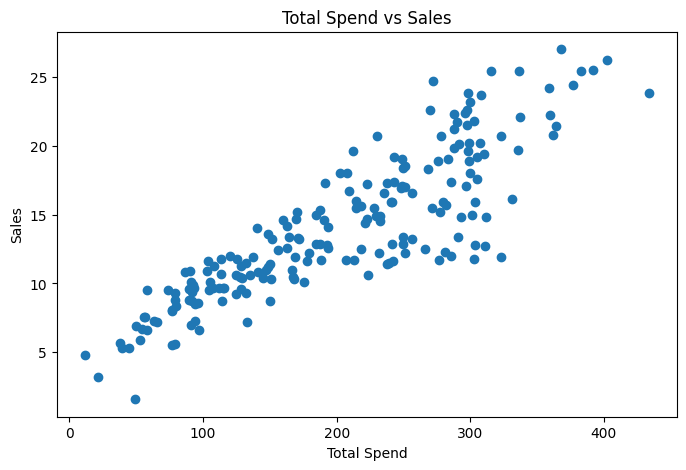

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(df["total_spend"], df["Sales"])

plt.xlabel("Total Spend")
plt.ylabel("Sales")
plt.title("Total Spend vs Sales")

plt.show()





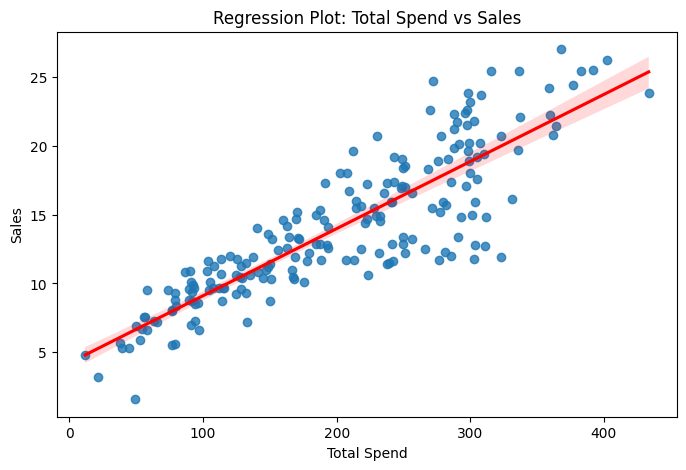

In [13]:



plt.figure(figsize=(8, 5))

sns.regplot(
    x="total_spend",
    y="Sales",
    data=df,
    line_kws={"color": "red"}
)

plt.xlabel("Total Spend")
plt.ylabel("Sales")
plt.title("Regression Plot: Total Spend vs Sales")

plt.show()



In [14]:



#     y = B1X + B0


print("\n LINEAR REGRESSION ")

# X = Feature
X = df[["total_spend"]]

# y = Target
y = df["Sales"]


# Create Linear Regression model
model = LinearRegression()

# Train/Fit the model
model.fit(X, y)


# Beta coefficient (B1)
B1 = model.coef_[0]

# Intercept (B0)
B0 = model.intercept_

print("Beta coefficient (B1):", B1)
print("Intercept (B0):", B0)



# y = B1X + B0

df["potential_sales"] = B1 * df["total_spend"] + B0


# Calculate predicted sales using model
df["predicted_sales"] = model.predict(X)


print("\nFirst 10 rows:")
print(df[[
    "total_spend",
    "Sales",
    "potential_sales",
    "predicted_sales"
]].head(10))


# Regression equation
print("\nRegression Equation:")
print("Sales =", B1, "* Total_Spend +", B0)



 LINEAR REGRESSION 
Beta coefficient (B1): 0.048687879319048145
Intercept (B0): 4.243028216036331

First 10 rows:
   total_spend  Sales  potential_sales  predicted_sales
0        337.1   22.1        20.655712        20.655712
1        128.9   10.4        10.518896        10.518896
2        132.4    9.3        10.689303        10.689303
3        251.3   18.5        16.478292        16.478292
4        250.0   12.9        16.414998        16.414998
5        132.6    7.2        10.699041        10.699041
6        113.8   11.8         9.783709         9.783709
7        151.4   13.2        11.614373        11.614373
8         11.7    4.8         4.812676         4.812676
9        223.6   10.6        15.129638        15.129638

Regression Equation:
Sales = 0.048687879319048145 * Total_Spend + 4.243028216036331


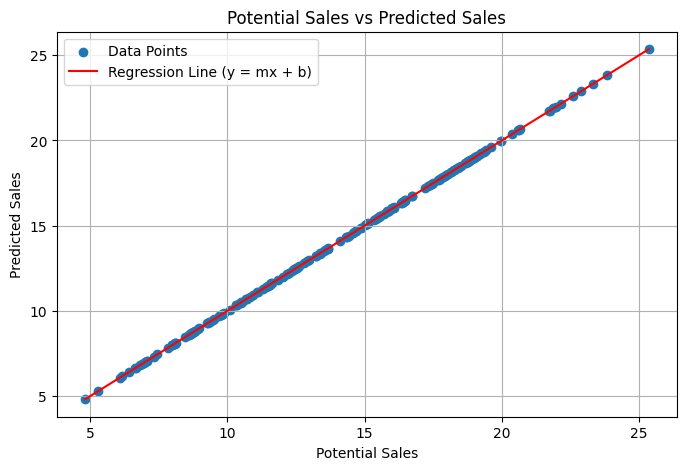


Comparison of Potential Sales and Predicted Sales:
   potential_sales  predicted_sales
0        20.655712        20.655712
1        10.518896        10.518896
2        10.689303        10.689303
3        16.478292        16.478292
4        16.414998        16.414998
5        10.699041        10.699041
6         9.783709         9.783709
7        11.614373        11.614373
8         4.812676         4.812676
9        15.129638        15.129638

Observation:
Potential sales and predicted sales are almost the same
because both are calculated using the same linear regression equation.
Therefore, the data points should lie close to the regression line.


========== Q10: PREDICTION FOR $200 SPEND ==========
Spend amount: $ 200
Expected unit sales: 13.98060407984596

Final Answer:
When the total spend is $200, expected unit sales are approximately 13.98


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:





plt.figure(figsize=(8, 5))

# Scatter plot
plt.scatter(
    df["potential_sales"],
    df["predicted_sales"],
    label="Data Points"
)

# Regression line
x_line = np.linspace(
    df["potential_sales"].min(),
    df["potential_sales"].max(),
    100
)

y_line = x_line

plt.plot(
    x_line,
    y_line,
    color="red",
    label="Regression Line (y = mx + b)"
)

plt.xlabel("Potential Sales")
plt.ylabel("Predicted Sales")
plt.title("Potential Sales vs Predicted Sales")

plt.legend()
plt.grid(True)

plt.show()


# Compare potential sales and predicted sales
print("\nComparison of Potential Sales and Predicted Sales:")
print(df[[
    "potential_sales",
    "predicted_sales"
]].head(10))


print("\nObservation:")
print("Potential sales and predicted sales are almost the same")
print("because both are calculated using the same linear regression equation.")
print("Therefore, the data points should lie close to the regression line.")




print("\n\n========== Q10: PREDICTION FOR $200 SPEND ==========")

# Spend = $200
spend = 200

# Predict sales
expected_sales = model.predict([[spend]])

print("Spend amount: $", spend)
print("Expected unit sales:", expected_sales[0])

print("\nFinal Answer:")
print(
    "When the total spend is $200, expected unit sales are approximately",
    round(expected_sales[0], 2)
)

In [16]:


print("\n\n========== Q10: PREDICTION FOR $200 SPEND ==========")

# Spend = $200
spend = 200

# Predict sales
expected_sales = model.predict([[spend]])

print("Spend amount: $", spend)
print("Expected unit sales:", expected_sales[0])

print("\nFinal Answer:")
print(
    "When the total spend is $200, expected unit sales are approximately",
    round(expected_sales[0], 2)
)



========== Q10: PREDICTION FOR $200 SPEND ==========
Spend amount: $ 200
Expected unit sales: 13.98060407984596

Final Answer:
When the total spend is $200, expected unit sales are approximately 13.98


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
